# Sensivity Analysis

## 1. Input data and first test





In [ ]:
import heco
output = heco.run('heco_sens_an.yaml')
# 50 min if run with cmems live web API
# seconds if use local dataset downloaded from CMEMS (see README.md)

Fetching catalog:   0%|          | 0/4 [00:00<?, ?it/s]

WARNING - 2026-07-15T04:46:39Z - Failed to parse portal catalogue: 'services'. Only using stac catalogue.


Fetching catalog: 100%|██████████| 4/4 [00:23<00:00,  5.97s/it]


INFO - 2026-07-15T04:47:02Z - Dataset version was not specified, the latest one was selected: "202511"
INFO - 2026-07-15T04:47:02Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2026-07-15T04:47:43Z - Service was not specified, the default one was selected: "arco-geo-series"
INFO - 2026-07-15T04:47:45Z - Dataset version was not specified, the latest one was selected: "202511"
INFO - 2026-07-15T04:47:45Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2026-07-15T04:47:46Z - Service was not specified, the default one was selected: "arco-geo-series"
Access to Cmems data using API successful
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill st

In [2]:
# save result to csv
output.to_csv('heco_results.csv', index=False)

# Save point to geojson with geopandas
import geopandas as gpd
gdf = gpd.GeoDataFrame(output, geometry=gpd.points_from_xy(output.lon, output.lat))
gdf.crs = "EPSG:4326"
gdf.to_file('heco_results.geojson', driver='GeoJSON')

print('Simulation results saved to heco_results.csv and heco_results.geojson')

Simulation results saved to heco_results.csv and heco_results.geojson


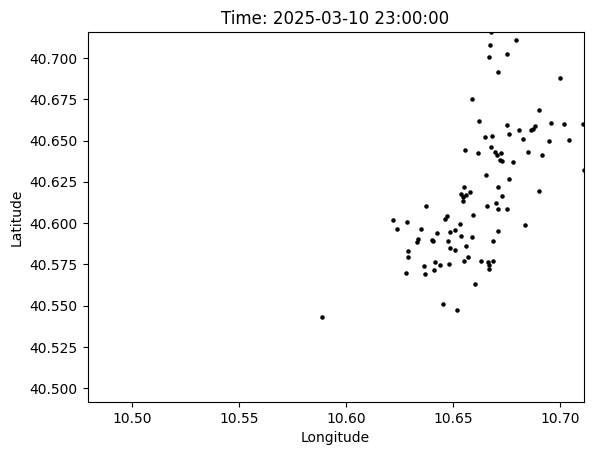

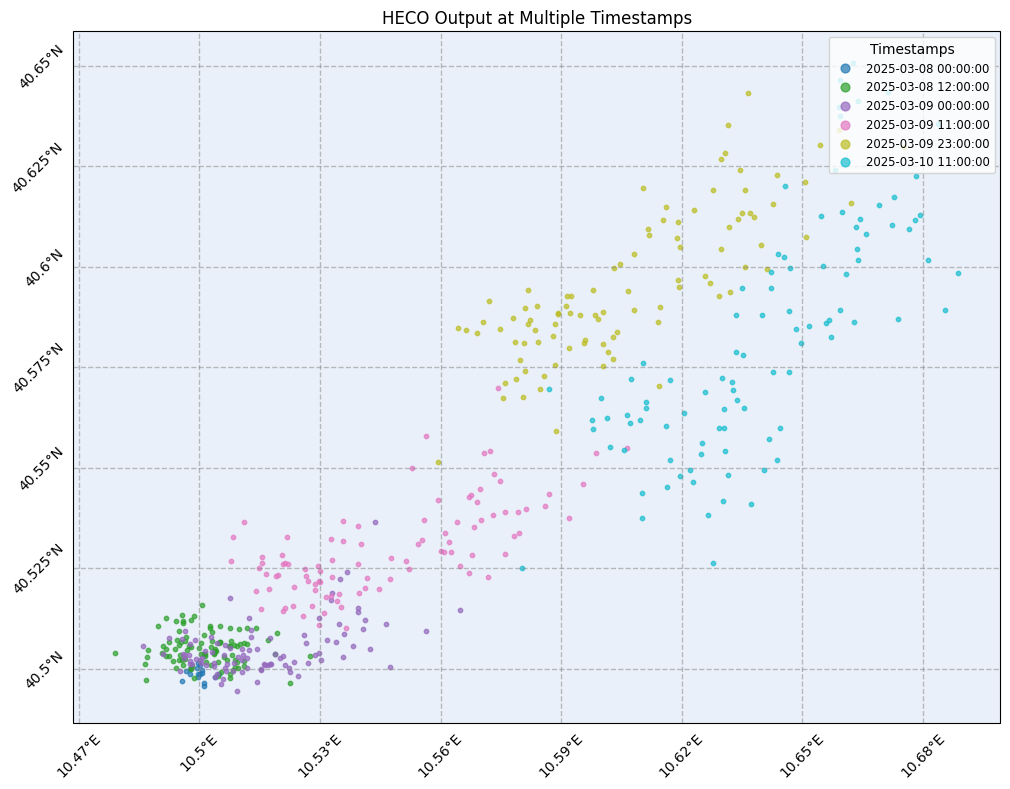

In [4]:

heco.create_points_animation('heco_results.geojson','heco_results.gif')
heco.multitimestamp_plot(output, 6)
# export webmap

heco.create_webmap(
    HECOpoint_output_gdf_path = 'heco_results.geojson',
    EMODnetLayers = True,
    settingsFile_path = 'heco_sens_an.yaml',
    output_path = 'heco_map.html',
    savepolygons = True
)